In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [98]:
df= pd.read_csv('../data/train.csv')

df.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [99]:
df.isnull().sum().sort_values(ascending=False).head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64

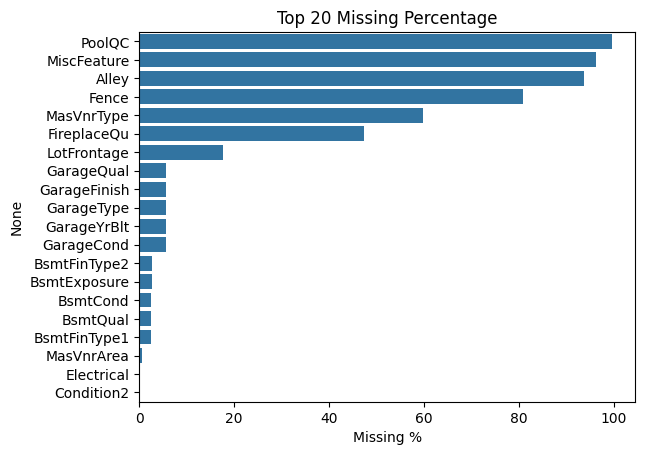

In [100]:
missing_pct = (df.isnull().sum()/len(df)*100).sort_values(ascending=False)

sns.barplot(
    x=missing_pct.head(20).values,
    y=missing_pct.head(20).index
)
plt.xlabel("Missing %")
plt.title("Top 20 Missing Percentage")
plt.show()

In [101]:
df.isnull().sum().sort_values(ascending=False).head(4)

PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
dtype: int64

In [102]:
drop_cols = [
    'PoolQC', 'MiscFeature','Alley','Fence'   
]

df = df.drop(drop_cols, axis=1)

In [103]:
df.isnull().sum().sort_values(ascending=False).head(4)

MasVnrType      872
FireplaceQu     690
LotFrontage     259
GarageFinish     81
dtype: int64

In [104]:
df['MasVnrType'].head(20)

0     BrkFace
1         NaN
2     BrkFace
3         NaN
4     BrkFace
5         NaN
6       Stone
7       Stone
8         NaN
9         NaN
10        NaN
11      Stone
12        NaN
13      Stone
14    BrkFace
15        NaN
16    BrkFace
17        NaN
18        NaN
19        NaN
Name: MasVnrType, dtype: str

In [105]:
df['MasVnrType'] = df['MasVnrType'].fillna("No_MasVnr")

In [106]:
df.isnull().sum().sort_values(ascending=False).head(4)

FireplaceQu     690
LotFrontage     259
GarageFinish     81
GarageYrBlt      81
dtype: int64

In [107]:
df['FireplaceQu'] = df['FireplaceQu'].fillna("N0_firePlace")

In [108]:
df['LotFrontage'].head(20)

0     65.0
1     80.0
2     68.0
3     60.0
4     84.0
5     85.0
6     75.0
7      NaN
8     51.0
9     50.0
10    70.0
11    85.0
12     NaN
13    91.0
14     NaN
15    51.0
16     NaN
17    72.0
18    66.0
19    70.0
Name: LotFrontage, dtype: float64

In [109]:
df['LotFrontage_missing'] = df['LotFrontage'].isnull().astype(int)

In [110]:
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())

In [111]:
df.isnull().sum().sort_values(ascending=False).head(6)

GarageType      81
GarageYrBlt     81
GarageCond      81
GarageFinish    81
GarageQual      81
BsmtFinType2    38
dtype: int64

In [112]:
garage_cols = ['GarageType','GarageCond','GarageFinish', 'GarageQual']

In [113]:
for col in garage_cols:
    df[col] = df[col].fillna("No_garage")

In [114]:
df.isnull().sum().sort_values(ascending=False).head(6)

GarageYrBlt     81
BsmtFinType2    38
BsmtExposure    38
BsmtQual        37
BsmtFinType1    37
BsmtCond        37
dtype: int64

In [115]:
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['GarageYrBlt'].median())

In [116]:
df.isnull().sum().sort_values(ascending=False).head(6)

BsmtExposure    38
BsmtFinType2    38
BsmtFinType1    37
BsmtQual        37
BsmtCond        37
MasVnrArea       8
dtype: int64

In [117]:
col_bsmt = [
    'BsmtExposure','BsmtFinType2','BsmtFinType1','BsmtQual','BsmtCond'
]

In [118]:
for col in col_bsmt:
    df[col] = df[col].fillna('No_Bsmt')

In [119]:
df.isnull().sum().sort_values(ascending=False).head(6)

MasVnrArea     8
Electrical     1
MSZoning       0
LotFrontage    0
Id             0
MSSubClass     0
dtype: int64

In [120]:
df['MasVnrArea'] = df['MasVnrArea'].fillna(df['MasVnrArea'].median()) 

In [121]:
df.isnull().sum().sort_values(ascending=False).head(6)

Electrical     1
Id             0
MSZoning       0
LotFrontage    0
LotArea        0
MSSubClass     0
dtype: int64

In [122]:
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

In [123]:
df.isnull().sum().sort_values(ascending=False)


Id                     0
MSSubClass             0
MSZoning               0
LotFrontage            0
LotArea                0
                      ..
YrSold                 0
SaleType               0
SaleCondition          0
SalePrice              0
LotFrontage_missing    0
Length: 78, dtype: int64

Now we do not have any null values. we will check for any duplicate values


In [124]:
df.duplicated().sum()

np.int64(0)

No Duplilcate values as  well.


In [125]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 78 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   1460 non-null   int64  
 1   MSSubClass           1460 non-null   int64  
 2   MSZoning             1460 non-null   str    
 3   LotFrontage          1460 non-null   float64
 4   LotArea              1460 non-null   int64  
 5   Street               1460 non-null   str    
 6   LotShape             1460 non-null   str    
 7   LandContour          1460 non-null   str    
 8   Utilities            1460 non-null   str    
 9   LotConfig            1460 non-null   str    
 10  LandSlope            1460 non-null   str    
 11  Neighborhood         1460 non-null   str    
 12  Condition1           1460 non-null   str    
 13  Condition2           1460 non-null   str    
 14  BldgType             1460 non-null   str    
 15  HouseStyle           1460 non-null   str    
 16 

All Dytpes are also correct

In [126]:
df.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,LotFrontage_missing
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,2,2008,WD,Normal,208500,0
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,0,0,0,5,2007,WD,Normal,181500,0
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,0,9,2008,WD,Normal,223500,0


<Axes: xlabel='SalePrice', ylabel='Count'>

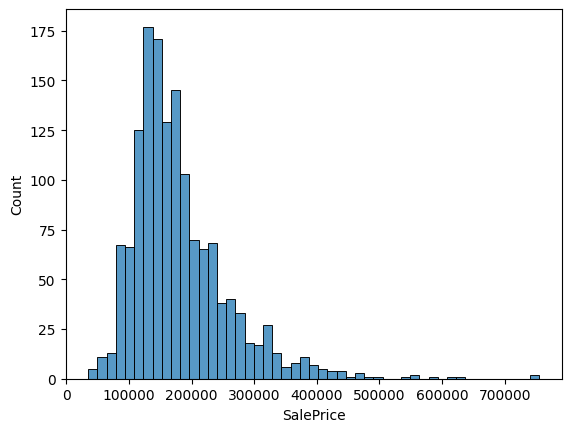

In [127]:
sns.histplot(df['SalePrice'])

now before making the Train and testing sets we need to normalize the value for the SalePrice as it is in very high number so we are going to use the transformation featuring for it.

In [128]:
df['Log_SalePrice'] = np.log1p(df['SalePrice'])

<Axes: xlabel='Log_SalePrice', ylabel='Count'>

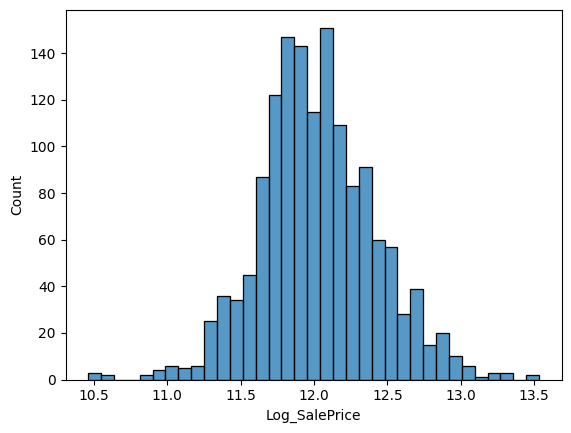

In [129]:
sns.histplot(df['Log_SalePrice'])

this is dataset is fulling cleaned and featured

In [130]:
print('Shape of tables: ', df.shape)
print('Null Values: ',df.isnull().sum().sum())
print('Duplicated Values: ',df.duplicated().sum())

Shape of tables:  (1460, 79)
Null Values:  0
Duplicated Values:  0


In [131]:
df.to_csv('../data/Cleaned_train.csv', index=False)

now we will spilt the features and target

In [132]:
df.head(1)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,LotFrontage_missing,Log_SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,2,2008,WD,Normal,208500,0,12.247699


In [133]:
X = df.drop(df[['SalePrice','Log_SalePrice']], axis=1)

y = df['Log_SalePrice']

print('Shape of X: ', X.shape)
print('Shape of X: ', y.shape)


Shape of X:  (1460, 77)
Shape of X:  (1460,)


now we will make the numeric features and categorical features

In [134]:
numeric_features = X.select_dtypes(
    include = ['int64','float64']
).columns

categorical_features = X.select_dtypes(
    include= ['str']
).columns



Now we will make feature pipelines

In [135]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

In [136]:
numericpp = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

catergoricalpp  = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

Now we will make the preprocessor for the decision tree regeression pipeline. we need the column transformer for this.

In [137]:
from sklearn.compose import ColumnTransformer

In [138]:
prepro = ColumnTransformer([
    ('num', numericpp, numeric_features),
    ('cat', catergoricalpp, categorical_features)
])

Now we make the decisiontree pipeline

In [139]:
from sklearn.tree import DecisionTreeRegressor

In [140]:
dtpp = Pipeline([
    ('preprocessor', prepro),
    ('model', DecisionTreeRegressor(random_state=42) )
])

Now we will split the training and testing sets

In [141]:
from sklearn.model_selection import train_test_split


In [142]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=.20, random_state=42
)

print('shape of X_train: ', X_train.shape )
print('shape of X_test: ', X_test.shape )
print('shape of y_train: ', y_train.shape )
print('shape of y_test: ', y_test.shape )



shape of X_train:  (1168, 77)
shape of X_test:  (292, 77)
shape of y_train:  (1168,)
shape of y_test:  (292,)


In [143]:
dtpp.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [144]:
dt_pred = dtpp.predict(X_test)

Now we will evaluate the prediction

In [145]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    mean_squared_error,
    r2_score   
)

In [146]:
print('R2 Score: ', r2_score(y_test,dt_pred))
print('MAE: ', mean_absolute_error(y_test, dt_pred))
print('MSE: ', mean_squared_error(y_test,dt_pred))
print('RMSE: ', root_mean_squared_error(y_test,dt_pred))

R2 Score:  0.7752169643306908
MAE:  0.1478076603422499
MSE:  0.041946984504293267
RMSE:  0.20480962991103047
